In [1]:
#!/usr/bin/env python
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
import re
import math
import glob
import warnings
# Suppress all warnings
# warnings.filterwarnings("ignore")
# sys.stdout = open(os.devnull,'w')


In [2]:
####### check logs
# dropbox_root='/media/plotnips/sdd1/Dropbox'
# # dropbox_root='/Users/pavelplotnitskii/Dropbox'
# folder_milanX=os.path.join(dropbox_root,'Apps/download_to_laptop/rtm_tests_milanx/')
os.getcwd()
folder_genoa=os.path.join('./data/par_search/')
save_path='/media/plotnips/sdd1/Dropbox/Apps/Overleaf/pavel_phd_thesis/fig/rtm/figures/performances/'

In [3]:
def read_data_stencil_modeling(filename):
    ###
    # read SB data from stencil-main logging files 
    ### 
    times=[]
    giga_points=[]
    giga_flops=[]
    point_updates=[]
    flops=[]
    method=[]
    grids=[]
    cores=[]
    cb_size=[]
    cb_x=[]
    cb_y=[]
    cb_z=[]
    thx=[]
    thy=[]
    thz=[]
    tdim=[]
    numwf=[]
    ##################
    tmp_ncores=math.nan
    tmp_time=math.nan
    tmp_giga_points=math.nan
    tmp_giga_flops=math.nan
    tmp_point_updates=math.nan
    tmp_flops=math.nan
    tmp_grid=math.nan
    tmp_cb_x=math.nan
    tmp_cb_y=math.nan
    tmp_cb_z=math.nan
    tmp_thx=math.nan
    tmp_thy=math.nan
    tmp_thz=math.nan
    tmp_tdim=math.nan
    tmp_numwf=math.nan
    tmp_mode=math.nan
    tmp_diam_width=math.nan
    tmp_method=math.nan
    tmp_cb_size=math.nan
    counter=0
    ##################
    ###### Parse files and aggregate them into the dataframe #######################
    print(os.getcwd())
    if not os.path.exists(filename):
        print(f"Warning: File '{filename}' not found. Skipping.")
        return None
    with open(os.path.join(filename),'r') as file:
        previous_line=''
        for line in file:
            if ('Program started at' in line):
                tmp_time=math.nan
                tmp_giga_points=math.nan
                tmp_giga_flops=math.nan
                tmp_point_updates=math.nan
                tmp_flops=math.nan
                tmp_grid=math.nan
                tmp_cb_x=math.nan
                tmp_cb_y=math.nan
                tmp_cb_z=math.nan
                tmp_thx=math.nan
                tmp_thy=math.nan
                tmp_thz=math.nan
                tmp_tdim=math.nan
                tmp_numwf=math.nan
                tmp_mode=math.nan
            if 'velocity size' in line and issubclass(type(tmp_grid),str)==False:
                pattern = r"velocity size\s*=\s*(\d+)\s*x\s*(\d+)\s*x\s*(\d+)"
                match = re.search(pattern,line)
                grid_x = int(match.group(1))
                grid_y = int(match.group(2))
                grid_z = int(match.group(3))
                tmp_grid = match.group(1)+" x "+match.group(2)+" x "+match.group(3)
            elif '[STENCIL MSG]:Total:' in line and '[STENCIL MSG]:Global info:' in previous_line:
                ### account for running time in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_time=float(number)
            elif '[STENCIL MSG]:Total:' in line and '[STENCIL MSG]:forward timer' in previous_line:
                ### account for running time in SB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_time=float(number)
            elif '[STENCIL MSG]:Total:' in line and '[STENCIL MSG]:Speed info:' in previous_line:
                ### account for performance in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_giga_points=float(number)
            elif '[STENCIL MSG]:PropSpeed:' in line and '[STENCIL MSG]:Speed:' in previous_line:
                ### account for performance in SB method
                pattern = r'\[STENCIL MSG\]:PropSpeed:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_giga_points=float(number)
            elif 'run 1st order' in line:
                if 'TB' in line:        tmp_method='tb_abc'
                if 'SB' in line:      tmp_method='sb_abc'
                if 'modeling' in line:      tmp_mode='modeling'
                if 'RTM' in line:      tmp_mode='rtm'
            elif '# THREADS' in line:
                tmp_ncores=(float(line.split()[-1]))
            elif 'BLOCKX=' in line:
                pattern = r"BLOCKX=(\d+)\s*,\s*BLOCKY=(\d+)\s*,\s*BLOCKZ=(\d+)"
                match = re.search(pattern,line)
                if match:
                    tmp_cb_x = int(match.group(1))
                    tmp_cb_y = int(match.group(2))
                    tmp_cb_z = int(match.group(3))
                tmp_cb_size=[tmp_cb_x,tmp_cb_y,tmp_cb_z]
            elif '[STENCIL MSG]:t_dim' in line and '[STENCIL MSG]:temporal blocking' in previous_line:
                # Define temporal blocking parameters in TB method
                pattern = r"\[STENCIL MSG\]:t_dim : (\d+), num_wf : (\d+), diam_width : (\d+)"
                match = re.search(pattern, line)
                if match:
                    tmp_tdim = int(match.group(1))  # t_dim
                    tmp_numwf = int(match.group(2))  # t_dim
                    tmp_diam_width = int(match.group(3))  # t_dim
            elif '[STENCIL MSG]:thread group' in line:
                pattern = r"\(\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\)"  # Matches (number,number,number)
                match = re.search(pattern, line)
                if match:
                    tmp_thx = int(match.group(1))  # Extract thx value
                    tmp_thy = int(match.group(2))  # Extract thy value
                    tmp_thz = int(match.group(3))  # Extract thz value
            elif ('[STENCIL MSG]:END of modeling' in line) or ('RTM HALAS' in line):
                cores.append(tmp_ncores)
                times.append(tmp_time)
                giga_points.append(tmp_giga_points)
                giga_flops.append(tmp_giga_flops)
                point_updates.append(tmp_point_updates)
                flops.append(tmp_flops)
                method.append(tmp_method)
                grids.append(tmp_grid)
                cb_size.append(tmp_cb_size)
                cb_x.append(tmp_cb_x)
                cb_y.append(tmp_cb_y)
                cb_z.append(tmp_cb_z)
                thx.append(tmp_thx)
                thy.append(tmp_thy)
                thz.append(tmp_thz)
                tdim.append(tmp_tdim)
                numwf.append(tmp_numwf)
                counter=counter+1
            previous_line=line
    ################################################
    # Créer un DataFrame à partir des listes
    data = pd.DataFrame({
        'method':method,
        'times':times,
        'giga_point_s':giga_points,
        'grids':grids,
        'cb_size':cb_size,
        'cb_x': cb_x,
        'cb_y': cb_y,
        'cb_z': cb_z,
        'cb_z': cb_z,
        'thx': thx,
        'thy': thy,
        'thz': thz,
        'tdim': tdim,
        'numwf': numwf
        })
    print(data.columns)
    return data


In [4]:

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
def plot_heat_map(map,title,x_label,y_label,xticks,yticks,save_path):
    # Create the figure with the specified size
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use make_axes_locatable to create a new axis for the colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)  # 'size' controls colorbar width, 'pad' controls spacing

    # Display the image
    im = ax.imshow(map.T, cmap='viridis', aspect='auto')

    # Add gridlines (if needed)
    ax.grid(True, color='black', linestyle='--', linewidth=0.5)

    # Create the colorbar and attach it to the new axis
    fig.colorbar(im, cax=cax, orientation='vertical')

    # Set plot title and labels (use ax for titles and labels)
    ax.set_title(title,fontsize=14)
    ax.set_xlabel(x_label,fontsize=14, fontweight='bold')  # Set your desired label for the X-axis
    ax.set_ylabel(y_label,fontsize=14, fontweight='bold')  # Set your desired label for the Y-axis

    # Set the x and y ticks with corresponding labels
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_xticklabels(xticks, rotation=45, fontweight='bold')  # You can rotate the labels if needed
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_yticklabels(yticks, fontweight='bold')

    print('save to ',save_path)
    # Save the figure with high resolution
    plt.savefig(save_path, dpi=400, bbox_inches='tight')

    # Show the plot
    plt.show()

    # Close the plot to free resources
    # plt.close()
    return None
tick_label_size=11

In [5]:
cbx_val=np.arange(2, 65, 2);cbx_val = np.insert(cbx_val, 0, 1)
cby_val=np.arange(2, 65, 2);cby_val = np.insert(cby_val, 0, 1)
nx=len(cbx_val)
ny=len(cby_val)
grids_=['512 x 512 x 512','1024 x 1024 x 512','2048 x 2048 x 512']

In [6]:
sb_data=read_data_stencil_modeling(os.path.join(folder_genoa,'test2_united.log'))   #sb_data
tb_data=read_data_stencil_modeling(os.path.join(folder_genoa,'test3_united.log'))
data=pd.concat([sb_data,tb_data])
# data=pd.concat([sb_data,tb_data],ignore_index=True)
data_summary=data.copy()
####################### Create summary for dataframe  #######################
### data_summary = data[['method', 'grids', 'times', 'giga_point_s', 'cb_size','cb_x','cb_y','cb_z']]

/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')
/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')


# Genoa 1024 x 1024 x 512

['1024 x 1024 x 512']
save to  /media/plotnips/sdd1/Dropbox/Apps/Overleaf/pavel_phd_thesis/fig/rtm/figures/performances/genoa_sb_1st_1024.png


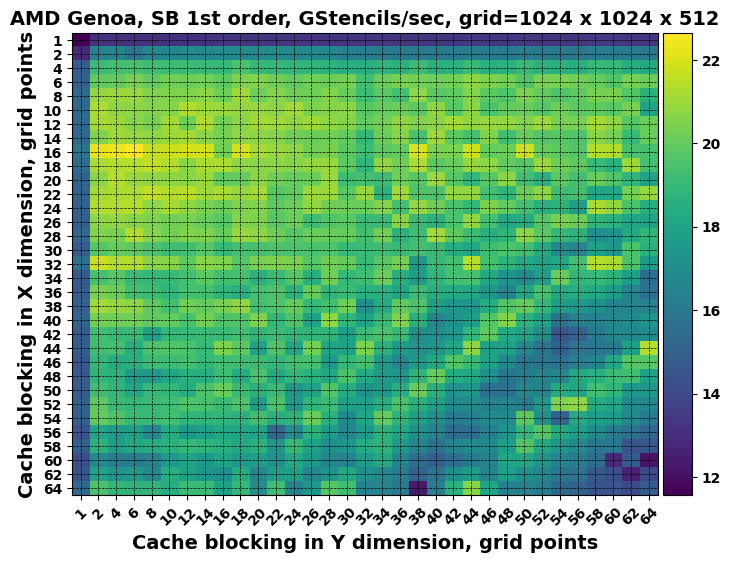

In [7]:
grid_name='1024 x 1024 x 512'
perf_map_1st = np.ones((ny,nx))*(float('nan'))
####################### Find best parameters for SB 1st order #######################
data_summary_1st = data_summary[data_summary['method'] == 'sb_abc']
data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
print(data_summary_1st['grids'].unique())
len(data_summary_1st)

for i in range(len(data_summary_1st)):  # Loops from 0 to 4
    if (data_summary_1st.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_1st.iloc[i]['cb_x']
        cb_y_value = data_summary_1st.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_1st[y_index,x_index] = data_summary_1st.iloc[i]['giga_point_s']
        if data_summary_1st.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_1st
title_='AMD Genoa, SB 1st order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
file_save_path=os.path.join(save_path,'genoa_sb_1st_1024.png')

plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,file_save_path)
##########################################################################################
##########################################################################################

# Genoa 512 x 512 x 512

['512 x 512 x 512']
save to  /media/plotnips/sdd1/Dropbox/Apps/Overleaf/pavel_phd_thesis/fig/rtm/figures/performances/genoa_sb_1st_512.png


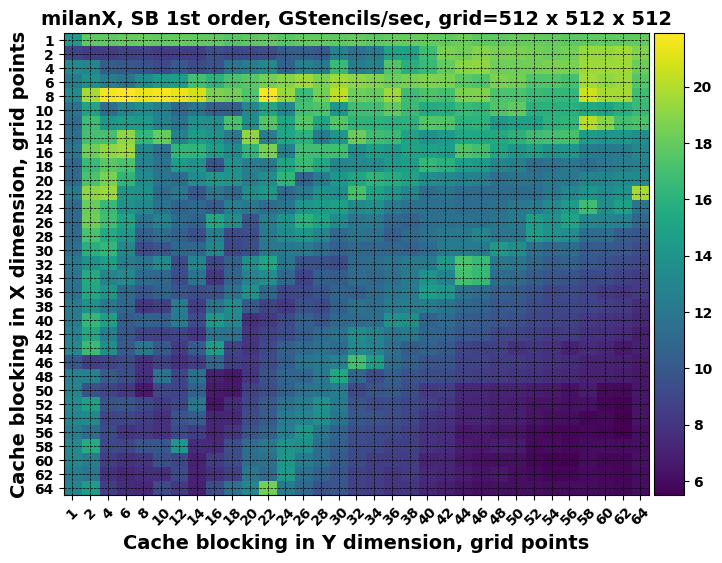

In [8]:
grid_name='512 x 512 x 512'
perf_map_1st = np.ones((ny,nx))*(float('nan'))
####################### Find best parameters for SB 1st order #######################
data_summary_1st = data_summary[data_summary['method'] == 'sb_abc']
data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
print(data_summary_1st['grids'].unique())
len(data_summary_1st)

for i in range(len(data_summary_1st)):  # Loops from 0 to 4
    if (data_summary_1st.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_1st.iloc[i]['cb_x']
        cb_y_value = data_summary_1st.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_1st[y_index,x_index] = data_summary_1st.iloc[i]['giga_point_s']
        if data_summary_1st.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_1st
title_='milanX, SB 1st order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
file_save_path=os.path.join(save_path,'genoa_sb_1st_512.png')
plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,file_save_path)
########################################################################


### Best params for SB cache blocking

In [9]:
best_parameters_SB=pd.DataFrame()
for grid_name in grids_:
    ####################### Find best parameters for SB 1st order #######################
    data_summary_1st = data_summary[data_summary['method'] == 'sb_abc']
    data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
    data_summary_1st=data_summary_1st.sort_values(by=['giga_point_s'],ascending=False)
    best_parameters_SB=pd.concat([best_parameters_SB,data_summary_1st.iloc[0]])
print(best_parameters_SB)

                         135                1356               2910
method                 sb_abc                NaN                NaN
times                3.242923                NaN                NaN
giga_point_s        21.902229                NaN                NaN
grids         512 x 512 x 512                NaN                NaN
cb_size          [8, 6, 9999]                NaN                NaN
cb_x                      8.0                NaN                NaN
cb_y                      6.0                NaN                NaN
cb_z                   9999.0                NaN                NaN
thx                       NaN                NaN                NaN
thy                       NaN                NaN                NaN
thz                       NaN                NaN                NaN
tdim                      NaN                NaN                NaN
numwf                     NaN                NaN                NaN
method                    NaN             sb_abc

### Best params for TB temporal blocking

In [10]:
best_parameters_TB=pd.DataFrame()
for grid_name in grids_[0:2]:
    ####################### Find best parameters for TB 1st order #######################
    data_summary_1st = data_summary[data_summary['method'] == 'tb_abc']
    data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
    data_summary_1st=data_summary_1st.sort_values(by=['giga_point_s'],ascending=False)
    best_parameters_TB=pd.concat([best_parameters_TB,data_summary_1st.iloc[0]])
print(best_parameters_TB)

                         939                1811
method                 tb_abc                NaN
times                1.150095                NaN
giga_point_s        46.913972                NaN
grids         512 x 512 x 512                NaN
cb_size                   NaN                NaN
cb_x                      NaN                NaN
cb_y                      NaN                NaN
cb_z                      NaN                NaN
thx                      16.0                NaN
thy                       2.0                NaN
thz                       1.0                NaN
tdim                      7.0                NaN
numwf                   192.0                NaN
method                    NaN             tb_abc
times                     NaN           5.327996
giga_point_s              NaN          40.507185
grids                     NaN  1024 x 1024 x 512
cb_size                   NaN                NaN
cb_x                      NaN                NaN
cb_y                

### TEST 1. "Performance" graphs for modeling.

In [11]:
perf_data=read_data_stencil_modeling(os.path.join(folder_genoa,'test1_forward_pasc.log'))
perf_data_summary=perf_data.copy()

/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')


In [12]:
perf_data_summary

,method,times,giga_point_s,grids,cb_size,cb_x,cb_y,cb_z,thx,thy,thz,tdim,numwf
0,sb_abc,7.982082,21.019298,512 x 512 x 512,"[8, 6, 9999]",8.0,6.0,9999.0,NaN,NaN,NaN,NaN,NaN
1,tb_abc,2.835623,47.806041,512 x 512 x 512,"[8, 6, 9999]",NaN,NaN,NaN,16.0,2.0,1.0,7.0,192.0
2,sb_abc,31.003863,20.911234,1024 x 1024 x 512,"[16, 6, 9999]",16.0,6.0,9999.0,NaN,NaN,NaN,NaN,NaN
3,tb_abc,10.751708,50.432881,1024 x 1024 x 512,"[16, 6, 9999]",NaN,NaN,NaN,4.0,2.0,1.0,3.0,20.0
4,sb_abc,118.153130,22.033625,2048 x 2048 x 512,"[22, 46, 9999]",22.0,46.0,9999.0,NaN,NaN,NaN,NaN,NaN
5,tb_abc,35.958860,60.317777,2048 x 2048 x 512,"[22, 46, 9999]",NaN,NaN,NaN,4.0,2.0,1.0,7.0,4.0


/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')


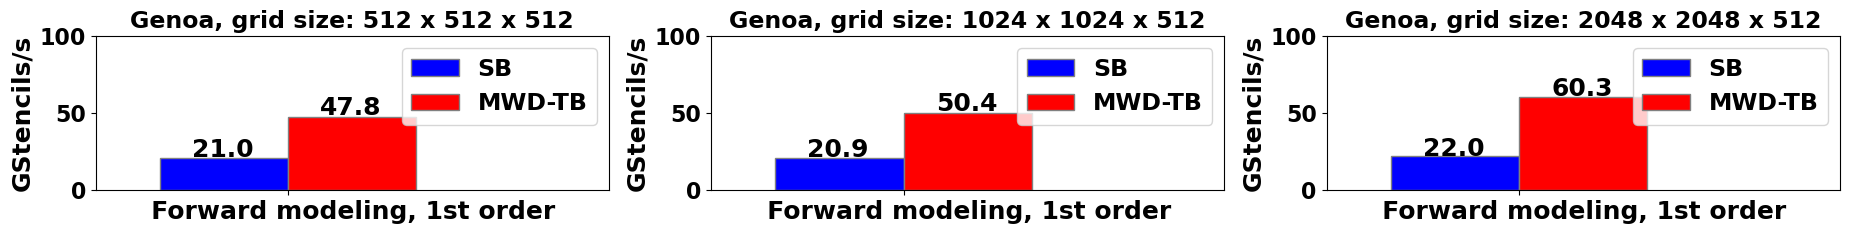

save to  /media/plotnips/sdd1/Dropbox/Apps/Overleaf/pavel_phd_thesis/fig/rtm/figures/performances/perf_fwd_genoa.png


In [13]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
tick_label_size=11
def plot_perf(data,save_paths,title='',metric='gstencils',gflops_limit=3300,gstencils_limit=100):
    barWidth = 0.2
    font = {'size': 17}
    plt.rc('font', **font)
    plt.rcParams["font.weight"]="bold"
    n_axis=3
    # fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),5))
    # fig, ax = plt.subplots(1,len(data_list),figsize=(22*len(data_list),2.0))  # first variant
    fig, ax = plt.subplots(1,n_axis,figsize=(7.5*n_axis,2.0))  # second variant
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.39, hspace=0.4)
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.2, hspace=0.5)
    # Set position of bar on X axis 
    br1 = np.arange(1)
    br2 = [x + barWidth for x in br1]
    
    grids=data['grids'].unique()
    ##### for (counter,data) in enumerate(data):
    for i_axis in range(n_axis):
        # Make the plot
        if n_axis==1:
            AX=ax
        else:
            AX=ax[i_axis]
        # print('data=',data)
        
        grid_name=grids[i_axis];
        data_grid=data[data['grids']==grid_name]
        data_grid[data_grid['method']=='sb_abc']
        SB=data_grid[data_grid['method']=='sb_abc'].iloc[0]['giga_point_s']
        TB=data_grid[data_grid['method']=='tb_abc'].iloc[0]['giga_point_s']
        

        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)

            if np.isfinite(yval):
                # AX.text(bar.get_x() - 0.04, yval + yval * 0.02, plot_val, fontsize=14, fontweight='bold')
                AX.text(bar.get_x() + 0.05, yval + yval * 0.02, plot_val, fontsize=18, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD-TB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)

            if np.isfinite(yval):
                AX.text(bar.get_x() + 0.05, yval + yval * 0.02, plot_val, fontsize=18, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

        # AX.set_xticks([r + barWidth for r in range(len(SB))],['Stencil', 'Stencil+ABCs'])
        AX.set_xticks([0.1,1.125],['               Forward modeling, 1st order','Forward modeling, 2nd order'], fontweight ='bold', fontsize = 18) # \n
        # AX.set_yticks(fontsize=15)
        # plt.yticks(fontsize=13)
        AX.tick_params(axis='y', labelsize=16)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            # AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 18)
            AX.set_ylabel('GStencils/s',fontweight ='bold',fontsize = 18)
            AX.set_ylim(bottom=0,top=gstencils_limit)
            AX.set_xlim(left=-0.2,right=0.6)
        AX.legend(loc='upper right')
        AX.set_title(title+', grid size: '+grid_name,fontweight='bold',fontsize=17)
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    # my_suptitle=fig.suptitle(title,fontsize=18,y=0,weight='bold')
    plt.show()
    print('save to ',save_paths[0]+'.png')
    fig.savefig(save_paths[0]+'.png',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[0]+'.pdf',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    return None
####################################################################################
#export FFLAGS="-march=znver4 -dynamic -m64 -Ofast -ffast-math -fopenmp -O3"
perf_data=read_data_stencil_modeling(os.path.join(folder_genoa,'test1_forward_pasc.log'))
save_paths=[os.path.join(save_path,'perf_fwd_genoa')]
plot_perf(perf_data,save_paths,title='Genoa',metric='gstencils',gstencils_limit=100)

/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')


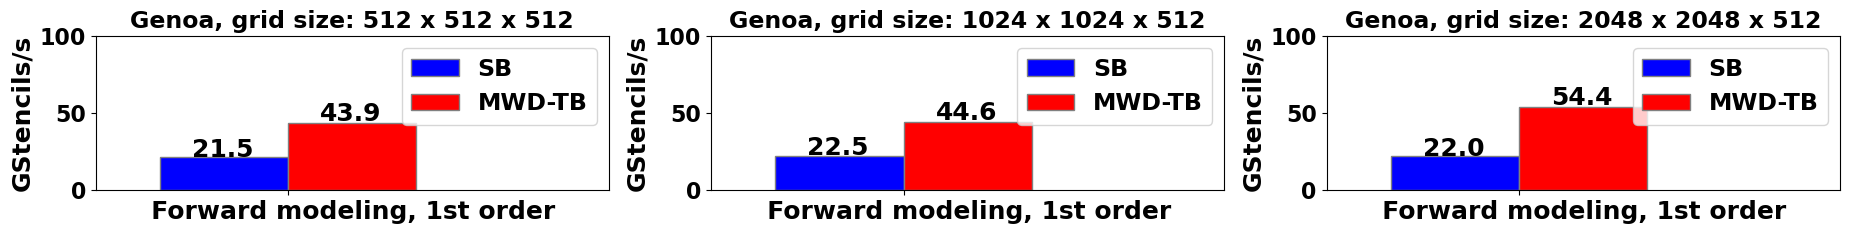

save to  /media/plotnips/sdd1/Dropbox/Apps/Overleaf/pavel_phd_thesis/fig/rtm/figures/performances/perf_fwd_genoa_attempt2.png


In [14]:
perf_data=read_data_stencil_modeling(os.path.join(folder_genoa,'test1_forward_pasc_better.log'))
save_paths=[os.path.join(save_path,'perf_fwd_genoa_attempt2')]
plot_perf(perf_data,save_paths,title='Genoa',metric='gstencils',gstencils_limit=100)

/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
Index(['method', 'times', 'giga_point_s', 'grids', 'cb_size', 'cb_x', 'cb_y',
       'cb_z', 'thx', 'thy', 'thz', 'tdim', 'numwf'],
      dtype='object')


IndexError: single positional indexer is out-of-bounds

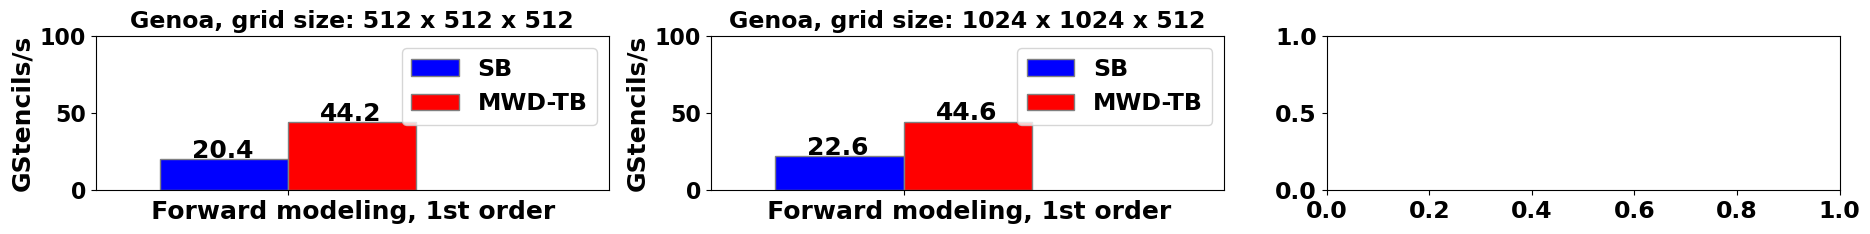

In [ ]:
# perf_data2=read_data_stencil_modeling(os.path.join(folder_genoa,'test1_forward_pasc_better2.log'))
# save_paths=[os.path.join(save_path,'perf_fwd_genoa_atempt4000')]
# plot_perf(perf_data2,save_paths,title='Genoa',metric='gstencils',gstencils_limit=100)

### RTM performance

/media/plotnips/sdd1/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/stencil_rtm_ordering/scripts_useful/python
512 x 512 x 512 [np.float64(19.13467), np.float64(15.771995), np.float64(17.453332500000002)] [np.float64(47.362835), np.float64(46.222978), np.float64(46.7929065)]
1024 x 1024 x 512 [np.float64(22.397613), np.float64(18.927023), np.float64(20.662318)] [np.float64(49.01339), np.float64(48.046832), np.float64(48.530111000000005)]
2048 x 2048 x 512 [np.float64(21.953828), np.float64(18.855654), np.float64(20.404741)] [np.float64(58.242899), np.float64(56.101302), np.float64(57.1721005)]


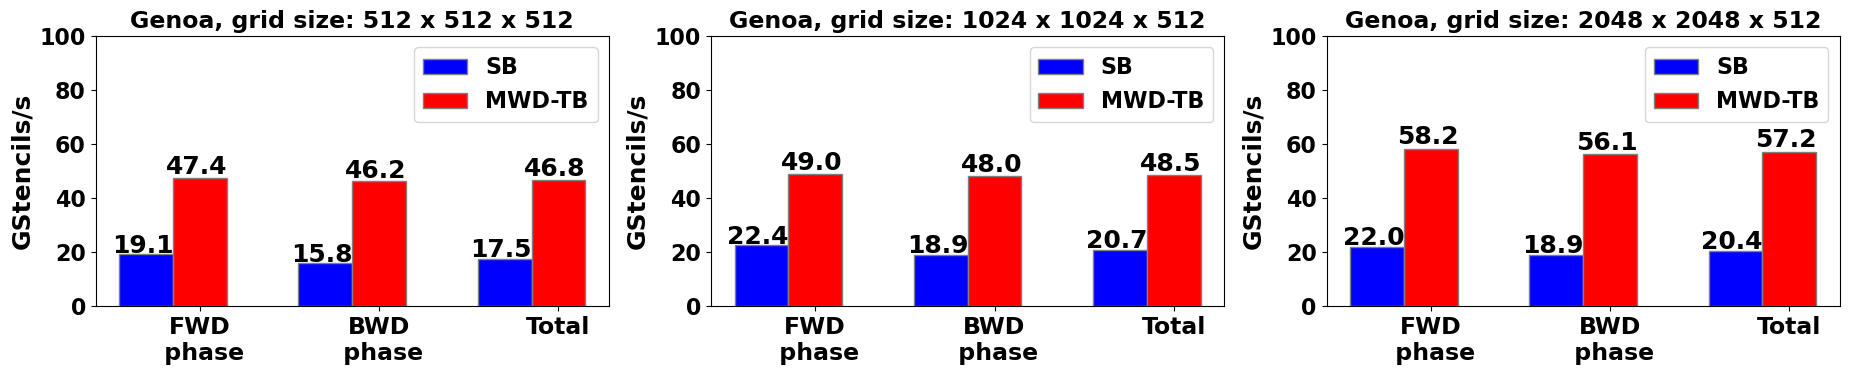

In [21]:
def read_data_stencil_rtm(filename):
    ###
    # read SB data from stencil-main logging files for
    # forward modeling (type 1) and RTM (type 2).
    ### 
    fwd_time=[]
    bwd_time=[]
    fwd_giga_points=[]
    bwd_giga_points=[]
    giga_flops=[]
    point_updates=[]
    flops=[]
    method=[]
    grids=[]
    cores=[]
    cb_size=[]
    cb_x=[]
    cb_y=[]
    cb_z=[]
    thx=[]
    thy=[]
    thz=[]
    tdim=[]
    numwf=[]
    mode=[]
    phase=[]
    shot=[]
    ##################
    counter=0
    tmp_rtm_phase=math.nan
    ##################
    ###### Parse files and aggregate them into the dataframe #######################
    print(os.getcwd())
    if not os.path.exists(filename):
        print(f"Warning: File '{filename}' not found. Skipping.")
        return None
    with open(os.path.join(filename),'r') as file:
        previous_line=''
        for line in file:
            # if ('Program started at' in line) or ('Before running RTM' in line): 
            # if ('Before running RTM' in line):
            if ('Hi' in line):
                #### ('Start of Shot' in line) or ('Processing shot ' in line)
                tmp_ncores=math.nan
                tmp_fwd_time=math.nan
                tmp_bwd_time=math.nan
                tmp_fwd_giga_points=math.nan
                tmp_bwd_giga_points=math.nan
                tmp_giga_flops=math.nan
                tmp_point_updates=math.nan
                tmp_flops=math.nan
                tmp_grid=math.nan
                tmp_cb_x=math.nan
                tmp_cb_y=math.nan
                tmp_cb_z=math.nan
                tmp_thx=math.nan
                tmp_thy=math.nan
                tmp_thz=math.nan
                tmp_tdim=math.nan
                tmp_numwf=math.nan
                tmp_diam_width=math.nan
                
                tmp_mode=math.nan
                tmp_rtm_phase=math.nan
                tmp_cb_size=math.nan
                tmp_method=math.nan
                tmp_mode=math.nan
                tmp_shot=math.nan
            elif 'run 1st order' in line:
                if 'TB' in line:        tmp_method='tb_abc'
                if 'SB' in line:      tmp_method='sb_abc'
                if 'modeling' in line:      tmp_mode='modeling'
                if 'RTM' in line:      tmp_mode='rtm'
            elif 'Start of Shot' in line:
                pattern_shot=r"Start of Shot\s*\(\s*(\d+)\s*\)"
                match_shot=re.search(pattern_shot,line)
                tmp_shot=int(match_shot.group(1))
            elif 'velocity size' in line:
                pattern = r"velocity size\s*=\s*(\d+)\s*x\s*(\d+)\s*x\s*(\d+)"
                match = re.search(pattern,line)
                tmp_grid = match.group(1)+" x "+match.group(2)+" x "+match.group(3)
            elif '# THREADS' in line:
                tmp_ncores=(float(line.split()[-1]))
            elif 'BLOCKX=' in line:
                pattern = r"BLOCKX=(\d+)\s*,\s*BLOCKY=(\d+)\s*,\s*BLOCKZ=(\d+)"
                match = re.search(pattern,line)
                if match:
                    tmp_cb_x = int(match.group(1))
                    tmp_cb_y = int(match.group(2))
                    tmp_cb_z = int(match.group(3))
                tmp_cb_size=[tmp_cb_x,tmp_cb_y,tmp_cb_z]
            elif '[STENCIL MSG]:t_dim' in line and '[STENCIL MSG]:temporal blocking' in previous_line:
                # Define temporal blocking parameters in TB method
                pattern = r"\[STENCIL MSG\]:t_dim : (\d+), num_wf : (\d+), diam_width : (\d+)"
                match = re.search(pattern, line)
                if match:
                    tmp_tdim = int(match.group(1))  # t_dim
                    tmp_numwf = int(match.group(2))  # t_dim
                    tmp_diam_width = int(match.group(3))  # t_dim
            elif '[STENCIL MSG]:thread group' in line:
                pattern = r"\(\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\)"  # Matches (number,number,number)
                match = re.search(pattern, line)
                if match:
                    tmp_thx = int(match.group(1))  # Extract thx value
                    tmp_thy = int(match.group(2))  # Extract thy value
                    tmp_thz = int(match.group(3))  # Extract thz value
            elif ('forward timer' in line) or ('FWD STEP' in line):
                tmp_rtm_phase='fwd'
            elif ('backward timer' in line) or ('BWD STEP' in line):
                tmp_rtm_phase='bwd'
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:Global info:' in previous_line) and tmp_rtm_phase=='fwd':
                ### account for running time in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_fwd_time=float(number)
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:Global info:' in previous_line) and tmp_rtm_phase=='bwd':
                ### account for running time in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_bwd_time=float(number)
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:forward timer' in previous_line) and tmp_rtm_phase=='fwd':
                ### account for running time in SB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_fwd_time=float(number)
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:backward timer' in previous_line) and tmp_rtm_phase=='bwd':
                ### account for running time in SB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*\(s\)'
                match = re.search(pattern, line)
                number = match.group(1)
                tmp_bwd_time=float(number)
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:Speed info:' in previous_line) and tmp_rtm_phase=='fwd' :
                ### account for performance in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_fwd_giga_points=float(number)
            elif ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:Speed info:' in previous_line) and tmp_rtm_phase=='bwd' :
                ### account for performance in TB method
                pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_bwd_giga_points=float(number)
            elif ('[STENCIL MSG]:Speed:' in line) and ('[STENCIL MSG]:SISMOS:' in previous_line)  and (tmp_rtm_phase=='fwd'):
                ### account for performance in SB method
                pattern = r'\[STENCIL MSG\]:Speed:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_fwd_giga_points=float(number)
            elif ('[STENCIL MSG]:Speed:' in line) and ('[STENCIL MSG]:IMAGE COND:' in previous_line)  and (tmp_rtm_phase=='bwd'):
                ### account for performance in SB method
                pattern = r'\[STENCIL MSG\]:Speed:\s*([\d.]+)\s*GStencils/s'
                match = re.search(pattern, line)
                if match:   number = match.group(1)
                tmp_bwd_giga_points=float(number)
            # elif ('[STENCIL MSG]:END of modeling' in line) or ('RTM HALAS' in line):
            elif ('RTM HALAS' in line):
                cores.append(tmp_ncores)
                method.append(tmp_method)
                mode.append(tmp_mode)
                phase.append(tmp_rtm_phase)
                shot.append(tmp_shot)

                fwd_time.append(tmp_fwd_time)
                bwd_time.append(tmp_bwd_time)
                fwd_giga_points.append(tmp_fwd_giga_points)
                bwd_giga_points.append(tmp_bwd_giga_points)

                giga_flops.append(tmp_giga_flops)
                point_updates.append(tmp_point_updates)
                flops.append(tmp_flops)
                grids.append(tmp_grid)
                cb_size.append(tmp_cb_size)
                cb_x.append(tmp_cb_x)
                cb_y.append(tmp_cb_y)
                cb_z.append(tmp_cb_z)
                thx.append(tmp_thx)
                thy.append(tmp_thy)
                thz.append(tmp_thz)
                tdim.append(tmp_tdim)
                numwf.append(tmp_numwf)
                counter=counter+1
            previous_line=line
    ################################################
    # Créer un DataFrame à partir des listes
    data = pd.DataFrame({
        'method':method,
        'mode':mode,
        'phase':phase,
        'shot': shot,
        'fwd_time':fwd_time,
        'bwd_time':bwd_time,
        'fwd_giga_points':fwd_giga_points,
        'bwd_giga_points':bwd_giga_points,
        'grids':grids,
        'cb_size':cb_size,
        'cb_x': cb_x,
        'cb_y': cb_y,
        'cb_z': cb_z,
        'cb_z': cb_z,
        'thx': thx,
        'thy': thy,
        'thz': thz,
        'tdim': tdim,
        'numwf': numwf
        })
    return data

#####################################################################
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
tick_label_size=11
def plot_perf_rtm(data,save_paths,title='',metric='gstencils',gflops_limit=3300,gstencils_limit=100):
    barWidth = 0.3
    font = {'size': 17}
    plt.rc('font', **font)
    plt.rcParams["font.weight"]="bold"
    n_axis=3
    # fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),5))
    # fig, ax = plt.subplots(1,len(data_list),figsize=(22*len(data_list),2.0))  # first variant
    fig, ax = plt.subplots(1,n_axis,figsize=(7.5*n_axis,3.5))  # second variant
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.39, hspace=0.4)
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.2, hspace=0.5)
    # Set position of bar on X axis 
    br1 = np.arange(3)
    br2 = [x + barWidth for x in br1]
    
    
    # grids=data['grids'].unique()
    grids=['512 x 512 x 512','1024 x 1024 x 512','2048 x 2048 x 512']
    ##### for (counter,data) in enumerate(data):
    for i_axis in range(n_axis):
        # Make the plot
        if n_axis==1:
            AX=ax
        else:
            AX=ax[i_axis]
        
        grid_name=grids[i_axis];
        data_grid=data[data['grids']==grid_name]
        data_grid[data_grid['method']=='sb_abc']

        SB_data=data_grid[data_grid['method']=='sb_abc']
        TB_data=data_grid[data_grid['method']=='tb_abc']

        SB=[]
        SB.append(SB_data.iloc[0]['fwd_giga_points'])
        SB.append(SB_data.iloc[0]['bwd_giga_points'])
        SB.append( (SB_data.iloc[0]['fwd_giga_points']+SB_data.iloc[0]['bwd_giga_points'])/2 )

        TB=[]
        TB.append(TB_data.iloc[0]['fwd_giga_points'])
        TB.append(TB_data.iloc[0]['bwd_giga_points'])
        TB.append( (TB_data.iloc[0]['fwd_giga_points']+TB_data.iloc[0]['bwd_giga_points'])/2 )
        print(grid_name,SB,TB)
        
        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            ### AX.text(bar.get_x()-0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')   # bold, normal
            if np.isfinite(yval):
                AX.text(bar.get_x() - 0.04, yval + yval * 0.03, plot_val, fontsize=18, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD-TB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            if np.isfinite(yval):
                AX.text(bar.get_x() - 0.04, yval + yval * 0.03, plot_val, fontsize=18, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

        x_labels=['FWD\n phase','BWD\n phase','Total']
        AX.set_xticks([r + barWidth for r in range(3)],x_labels, fontweight ='bold', fontsize = 17)
        # AX.set_xticks([0.125,1.125,2.125],x_labels, fontweight ='bold', fontsize = 18)
        AX.tick_params(axis='y', labelsize=16)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            AX.set_ylabel('GStencils/s',fontweight ='bold', fontsize = 18)
            AX.set_ylim(bottom=0,top=gstencils_limit)
        AX.legend(loc='upper right', fontsize = 16)
        AX.set_title(title+', grid size: '+grid_name,fontweight='bold',fontsize=17)
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    # my_suptitle=fig.suptitle(title,fontsize=18,y=0,weight='bold')
    plt.show()
    fig.savefig(save_paths[0]+'.png',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[0]+'.pdf',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    return None
###################################################################################
perf_data=read_data_stencil_rtm(os.path.join(folder_genoa,'test1_rtm_pasc_all_grids2.log'))
save_paths=[os.path.join(save_path,'perf_rtm_genoa')]
plot_perf_rtm(perf_data,save_paths,title='Genoa',metric='gstencils',gstencils_limit=100)

# Extract data for performances graphs, deprecated

In [ ]:
# warnings.filterwarnings("ignore")
# sys.stdout = open(os.devnull, 'w')
# sys.stdout = sys.__stdout__
# ####################### Plot bar charts #######################
# def plot_perf(data_list,save_paths,title='',metric='gstencils',gflops_limit=3300,gstencils_limit=100):
#     barWidth = 0.25
#     # fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),5))
#     font = {'size': 17};    
#     plt.rc('font', **font)
#     plt.rcParams["font.weight"]="bold"
#     # fig, ax = plt.subplots(1,len(data_list),figsize=(22*len(data_list),2.0))  # first variant
#     fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),2.0))  # second variant
#     # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.39, hspace=0.4)
#     # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.2, hspace=0.5)
#     # Set position of bar on X axis 
#     br1 = np.arange(2)
#     br2 = [x + barWidth for x in br1]
#     for (counter,data) in enumerate(data_list):
#         print('data=',data)
#         grid_name=data[0];
#         SB=[data[1],data[3]]; 
#         TB=[data[2],data[4]];
#         # Make the plot
#         if len(data_list)==1:
#             AX=ax
#         else:
#             AX=ax[counter]
        
#         bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
#         for bar in bars:
#             yval = bar.get_height()
#             if metric=='gflops':
#                 plot_val=int(yval)
#             else:
#                 plot_val=round(yval,1)
#             ### AX.text(bar.get_x()-0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')   # bold, normal
#             if np.isfinite(yval):
#                 AX.text(bar.get_x() - 0.04, yval + yval * 0.02, plot_val, fontsize=14, fontweight='bold')
#             else:
#                 print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")
        
#         bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD')
#         for bar in bars:
#             yval = bar.get_height()
#             if metric=='gflops':
#                 plot_val=int(yval)
#             else:
#                 plot_val=round(yval,1)
#             #### AX.text(bar.get_x()+0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')
#             if np.isfinite(yval):
#                 AX.text(bar.get_x() - 0.04, yval + yval * 0.02, plot_val, fontsize=14, fontweight='bold')
#             else:
#                 print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

#         # AX.set_xticks([r + barWidth for r in range(len(SB))],['Stencil', 'Stencil+ABCs'])
#         AX.set_xticks([0.125,1.125],['Stencil+ABCs,\n 1st order','Stencil+ABCs,\n 2nd order'], fontweight ='bold', fontsize = 15)
#         # AX.set_yticks(fontsize=15)
#         # plt.yticks(fontsize=13)
#         AX.tick_params(axis='y', labelsize=13)

#         if metric=='gflops':
#             AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 15)
#             AX.set_ylim(bottom=0,top=gflops_limit)
#         else:
#             # AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 18)
#             AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 15)
#             AX.set_ylim(bottom=0,top=gstencils_limit)
#         # AX.legend(loc='upper right')
#         # AX.legend(loc='upper left')
#         AX.legend(loc='upper center')
#         # AX.set_title('Grid size:\n'+grid_name,fontweight='bold',fontsize=14)
#         AX.set_title(title+', grid size:'+grid_name,fontweight='bold',fontsize=17)
#     my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
#     # my_suptitle=fig.suptitle(title,fontsize=18,y=0,weight='bold')
#     plt.show()
#     fig.savefig(save_paths[0]+'.png',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
#     fig.savefig(save_paths[0]+'.pdf',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
#     return None

# ###########################################################################
# data_list=[]
# # extract sb tb vals for all archs and grids
# archs=data_all['arch'].unique()
# # print(data_all['grids'].unique())
# metric='giga_point_s'
# for arch in archs:
#     # print(arch)
#     data_ = data_all[data_all['arch'] == arch]
#     data_list=[]
#     for grid in grids_:
#         data_list_=[]
#         # print(arch,grid)
#         data_grid=data_[data_['grids'] == grid]
#         # choose code type
#         data_grid_sb_abc=data_grid[data_grid['method']=='sb_abc']
#         data_grid_tb_abc=data_grid[data_grid['method']=='tb_abc']
#         data_grid_sb_order2_abc=data_grid[data_grid['method']=='sb_order2_abc']
#         data_grid_tb_order2_abc=data_grid[data_grid['method']=='tb_order2_abc']
#         # sort results by performance
#         data_grid_sb_abc=data_grid_sb_abc.sort_values(by=[metric],ascending=False)
#         data_grid_tb_abc=data_grid_tb_abc.sort_values(by=[metric],ascending=False)
#         data_grid_sb_order2_abc=data_grid_sb_order2_abc.sort_values(by=[metric],ascending=False)
#         data_grid_tb_order2_abc=data_grid_tb_order2_abc.sort_values(by=[metric],ascending=False)
#         #########################
#         ##### record 1st order results
#         if len(data_grid_sb_abc[metric].values)!=0:
#             sb_abc_val=data_grid_sb_abc[metric].values[0]
#         else:
#             sb_abc_val=math.nan
#         if len(data_grid_tb_abc[metric].values)!=0:
#             tb_abc_val=data_grid_tb_abc[metric].values[0]
#         else:
#             tb_abc_val=math.nan
#         ##### record 2nd order results
#         if len(data_grid_sb_order2_abc[metric].values)!=0:
#             sb_order2_abc_val=data_grid_sb_order2_abc[metric].values[0]
#         else:
#             sb_order2_abc_val=math.nan
#         if len(data_grid_tb_order2_abc[metric].values)!=0:
#             tb_order2_abc_val=data_grid_tb_order2_abc[metric].values[0]
#         else:
#             tb_order2_abc_val=math.nan
#         data_list_=[grid,sb_abc_val,tb_abc_val,sb_order2_abc_val,tb_order2_abc_val]
#         print(data_list_)
#         data_list.append(data_list_)
#     ########################
#     save_paths=['./'+arch+'_gstencils']
#     plot_perf(data_list,save_paths,title=arch,metric='gstencils',gstencils_limit=150)
#     print(data_list[-1])



In [ ]:
# !cp *.png* /home/plotnips/Dropbox/Apps/Overleaf/2025_01_stencil_report/figures/performances